# Why 30% of Swiggy Orders Are Delivered Late : A Data Case Study

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [116]:
df = pd.read_csv('Food_Delivery_Dataset.csv')
df.head(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [118]:
df.describe().round()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.0,45593.0,45593.0,45593.0,45593.0
mean,17.0,70.0,17.0,71.0,1.0
std,8.0,23.0,7.0,21.0,1.0
min,-31.0,-88.0,0.0,0.0,0.0
25%,13.0,73.0,13.0,73.0,0.0
50%,19.0,76.0,19.0,76.0,1.0
75%,23.0,78.0,23.0,78.0,2.0
max,31.0,88.0,31.0,89.0,3.0


# Handling Missing Values

#### Even without Null Values Few Columns have NaN as a value

In [119]:
df['Delivery_person_Age'].unique()

array(['37', '34', '23', '38', '32', '22', '33', '35', '36', '21', '24',
       '29', '25', '31', '27', '26', '20', 'NaN ', '28', '39', '30', '15',
       '50'], dtype=object)

In [120]:
df['Delivery_person_Ratings'].unique()

array(['4.9', '4.5', '4.4', '4.7', '4.6', '4.8', '4.2', '4.3', '4', '4.1',
       '5', '3.5', 'NaN ', '3.8', '3.9', '3.7', '2.6', '2.5', '3.6',
       '3.1', '2.7', '1', '3.2', '3.3', '6', '3.4', '2.8', '2.9', '3'],
      dtype=object)

In [121]:
df['Road_traffic_density'].unique()

array(['High ', 'Jam ', 'Low ', 'Medium ', 'NaN '], dtype=object)

In [122]:
df['multiple_deliveries'].unique()

array(['0', '1', '3', 'NaN ', '2'], dtype=object)

In [123]:
df['City'].unique()

array(['Urban ', 'Metropolitian ', 'Semi-Urban ', 'NaN '], dtype=object)

In [124]:
cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Time_Orderd', 'Road_traffic_density', 'multiple_deliveries', 'City']
df = df[df[cols].notna().all(axis=1)]
for col in cols:
    df = df[df[col].astype(str).str.strip() != 'NaN']

In [125]:
df['Weatherconditions'] = df['Weatherconditions'].replace('conditions NaN', np.nan)
df = df.dropna(subset = 'Weatherconditions')

In [126]:
df['Weatherconditions'].unique()

array(['conditions Sunny', 'conditions Stormy', 'conditions Sandstorms',
       'conditions Cloudy', 'conditions Fog', 'conditions Windy'],
      dtype=object)

In [127]:
cols = ['Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude']
for col in cols:
    df[col] = df[col].replace(0, np.nan)
df = df.dropna(subset = cols)

# Formatting Inconsistent Values

In [128]:
df['Weatherconditions'].unique()

array(['conditions Sunny', 'conditions Stormy', 'conditions Sandstorms',
       'conditions Cloudy', 'conditions Fog', 'conditions Windy'],
      dtype=object)

In [129]:
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', regex=False)

In [130]:
df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min) ', '', regex=False)
df['Time_taken(min)'] = df['Time_taken(min)'].astype('int64')

# Changing Datatypes

In [131]:
df['Delivery_person_Age'] = df['Delivery_person_Age'].astype('int64')
df['multiple_deliveries'] = df['multiple_deliveries'].astype('int64')

In [132]:
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].astype('float64')

In [133]:
df['Order_Date'] = df['Order_Date'].astype('datetime64[ns]')
df['Time_Orderd'] = df['Time_Orderd'].astype('datetime64[ns]')
df['Time_Order_picked'] = df['Time_Order_picked'].astype('datetime64[ns]')

In [134]:
df['Order_hour'] = df['Time_Orderd'].dt.hour
df['Order_minute'] = df['Time_Orderd'].dt.minute

In [135]:
df['Picked_hour'] = df['Time_Order_picked'].dt.hour
df['Picked_minute'] = df['Time_Order_picked'].dt.minute

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38243 entries, 0 to 45592
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           38243 non-null  object        
 1   Delivery_person_ID           38243 non-null  object        
 2   Delivery_person_Age          38243 non-null  int64         
 3   Delivery_person_Ratings      38243 non-null  float64       
 4   Restaurant_latitude          38243 non-null  float64       
 5   Restaurant_longitude         38243 non-null  float64       
 6   Delivery_location_latitude   38243 non-null  float64       
 7   Delivery_location_longitude  38243 non-null  float64       
 8   Order_Date                   38243 non-null  datetime64[ns]
 9   Time_Orderd                  38243 non-null  datetime64[ns]
 10  Time_Order_picked            38243 non-null  datetime64[ns]
 11  Weatherconditions            38243 non-null  o

In [137]:
# Extracting Late Delivery from Time_Taken
delay_threshold = 30   # minutes
df['Late_Delivery'] = df['Time_taken(min)'] > delay_threshold

## 1. What percentage of orders are Delivered late??

In [138]:
late_percentage = (df['Late_Delivery'].mean()) * 100
print(f'Late Delivery : {late_percentage:.2f}%')

Late Delivery : 30.59%


## 2. What is the Average delay time (in minutes) for late deliveries??

In [139]:
avg_delay = df[df['Late_Delivery']]['Time_taken(min)'].mean()
print(f'Average Delay Time : {avg_delay:.2f} minutes')

Average Delay Time : 37.95 minutes


## 3. How does Delivery Distance affect the probability of late Delivery??

In [140]:
# Calculating Distance using latitude and longitude
from geopy.distance import geodesic
def calc_distance(row):
    return geodesic((row['Restaurant_latitude'], row['Restaurant_longitude']),
                    (row['Delivery_location_latitude'], row['Delivery_location_longitude'])).km

df['distance_km'] = df.apply(calc_distance, axis = 1)

In [141]:
# Creating Distance bins to calculate late delivery probability
bins = [0,2,5,10,20]
labels = ['0-2 km', '2-5 km', '5-10 km', '10+ km']
df['Distance_Band'] = pd.cut(df['distance_km'], bins=bins, labels=labels)

late_prob = (df.groupby('Distance_Band')['Late_Delivery'].mean() * 100)
print(late_prob)

Distance_Band
0-2 km     10.361021
2-5 km     13.858175
5-10 km    21.551387
10+ km     46.215711
Name: Late_Delivery, dtype: float64


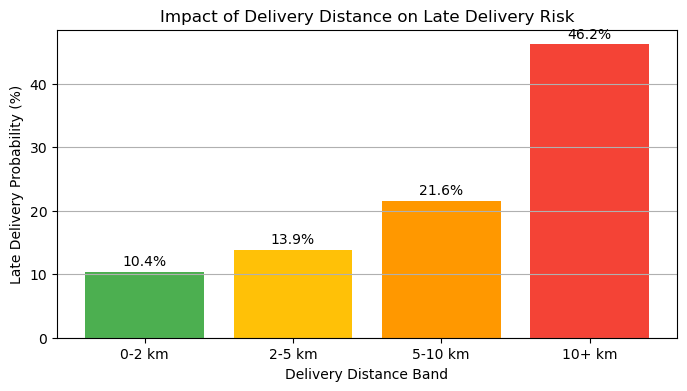

In [142]:
# Plot
plt.figure(figsize=(8,4))
colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
bars = plt.bar(late_prob.index.astype(str), late_prob.values,color=colors)

#Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height + 1,f'{height:.1f}%',ha='center',fontsize=10)

plt.title('Impact of Delivery Distance on Late Delivery Risk')
plt.xlabel('Delivery Distance Band')
plt.ylabel('Late Delivery Probability (%)')
plt.grid(axis='y')
plt.show()

## 4. During which hours of the day do late deliveries occur most frequently??

In [143]:
# Which hour have most late orders
late_by_hour = (df[df['Late_Delivery']].groupby('Order_hour').size().sort_values(ascending = False))
print(late_by_hour)

Order_hour
21    2094
20    2070
19    2037
18    1412
17    1369
22     600
11     527
23     499
12     255
13     248
14     223
15     122
16      93
8       46
10      39
0       33
9       30
dtype: int64


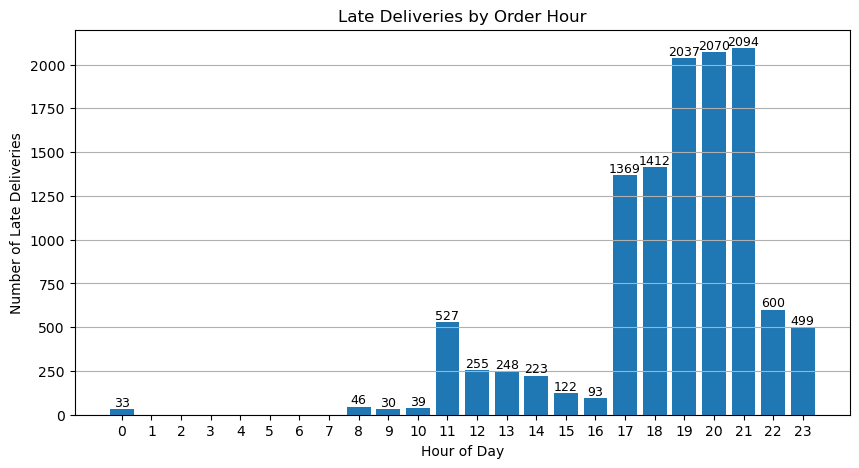

In [144]:
plt.figure(figsize=(10,5))
bars = plt.bar(late_by_hour.index, late_by_hour.values)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height,int(height),ha='center',va='bottom',fontsize=9)

plt.title('Late Deliveries by Order Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Late Deliveries')
plt.xticks(range(0,24))
plt.grid(axis='y')
plt.show()

## 5. Are late Deliveries more common on weekends compared to weekdays??

In [145]:
# Separated Weekdays and Weekends
df['Day_Name'] = df['Order_Date'].dt.day_name()
df['Is_Weekend'] = df['Day_Name'].isin(['Saturday', 'Sunday'])

In [146]:
# Comparing Late Delivery Probability
late_weekend = (df.groupby('Is_Weekend')['Late_Delivery'].mean() * 100)
print(late_weekend)

Is_Weekend
False    30.709087
True     30.260273
Name: Late_Delivery, dtype: float64


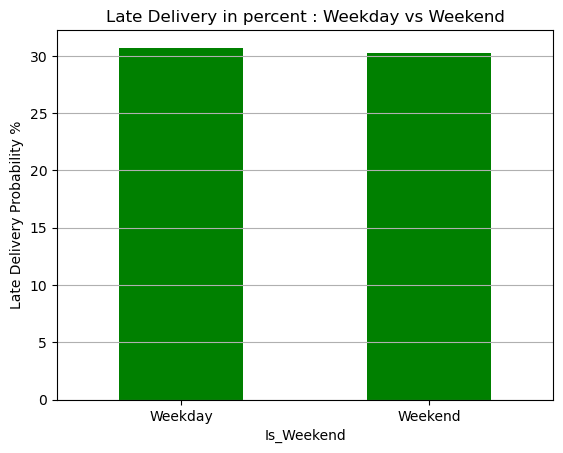

In [147]:
late_weekend.plot(kind='bar', color = 'g')
plt.title('Late Delivery in percent : Weekday vs Weekend')
plt.ylabel('Late Delivery Probability %')
plt.xticks([0,1], ['Weekday','Weekend'], rotation=0)
plt.grid(axis='y')
plt.show()

## 6. Which Cities or Areas have the highest late delivery Rates??

In [148]:
# Late Delivery rate per City
late_by_city = (df.groupby('City')['Late_Delivery'].mean() * 100).sort_values(ascending = False)
print(late_by_city)

City
Semi-Urban        100.000000
Metropolitian      33.640349
Urban              19.131537
Name: Late_Delivery, dtype: float64


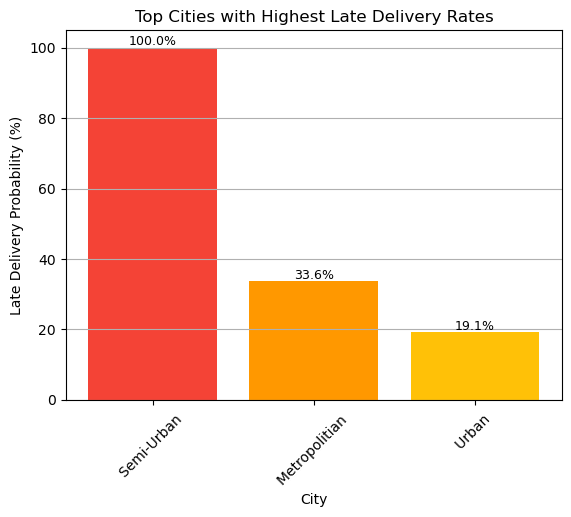

In [149]:
bars = plt.bar(late_by_city.index, late_by_city.values, color=['#F44336','#FF9800','#FFC107'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height,f'{height:.1f}%',ha='center',va='bottom',fontsize=9)

plt.title('Top Cities with Highest Late Delivery Rates')
plt.xlabel('City')
plt.ylabel('Late Delivery Probability (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## 7. What Order Characteristics (Distance, Time, Location) are most associated with late deliveries??

In [150]:
# Distance Vs Late Delivery
distance_delay = (df.groupby('Distance_Band')['Late_Delivery'].mean() * 100).sort_values(ascending = False)
print(distance_delay)

Distance_Band
10+ km     46.215711
5-10 km    21.551387
2-5 km     13.858175
0-2 km     10.361021
Name: Late_Delivery, dtype: float64


In [151]:
# Order Time(Hour) Vs Late Delivery
time_delay = (df.groupby('Order_hour')['Late_Delivery'].mean() * 100).sort_values(ascending = False)
print(time_delay.head(10))

Order_hour
20    51.750000
21    50.825243
19    49.914237
17    36.604278
13    36.417034
18    35.764944
14    32.650073
12    32.156368
11    30.746791
15    16.052632
Name: Late_Delivery, dtype: float64


In [152]:
# Location or City Vs Late Deliverey
city_delay = (df.groupby('City')['Late_Delivery'].mean() * 100).sort_values(ascending = False)
print(city_delay)

City
Semi-Urban        100.000000
Metropolitian      33.640349
Urban              19.131537
Name: Late_Delivery, dtype: float64


## 8. What percentage of late deliveries exceed the SLA by more than 10 minutes

In [153]:
# Percentage of late deliveries where delay > 10 mins beyond SLA
sla_time = 30
severe_buffer = 10

late_df = df[df['Time_taken(min)'] > sla_time]

#Severe late > 10 mins beyond SLA
severe_late = late_df[late_df['Time_taken(min)'] > (sla_time + severe_buffer)]

severe_percentage = (len(severe_late) / len(late_df)) * 100
print(f"Severe SLA Breach %: {severe_percentage:.2f}%")

Severe SLA Breach %: 29.69%


## 9. Are late deliveries significantly higher during peak hours??

In [154]:
peak_hours = [13, 17, 18, 19, 20, 21]
df['Is_Peak_Hour'] = df['Order_hour'].isin(peak_hours)

# Compare late delivery %
peak_delay = (df.groupby('Is_Peak_Hour')['Late_Delivery'].mean() * 100)
print(peak_delay)

Is_Peak_Hour
False    13.959147
True     44.871172
Name: Late_Delivery, dtype: float64


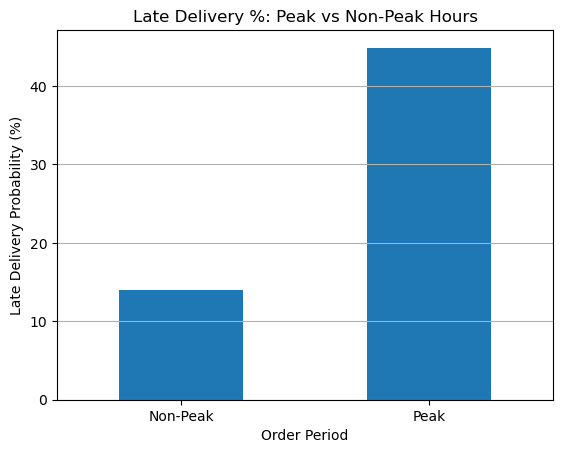

In [155]:
peak_delay.plot(kind='bar')

plt.title('Late Delivery %: Peak vs Non-Peak Hours')
plt.xlabel('Order Period')
plt.ylabel('Late Delivery Probability (%)')
plt.xticks([0,1], ['Non-Peak','Peak'], rotation=0)
plt.grid(axis='y')
plt.show()

## 10. How do average distance and order time differ between late and on time deliveries

In [156]:
comparison = (df.groupby('Late_Delivery').agg({'distance_km' : 'mean',
                                               'Order_hour' : 'mean'}))
comparison.index = ['On-Time', 'Late']
print(comparison)

         distance_km  Order_hour
On-Time    28.104444   16.936563
Late       28.338947   18.551081


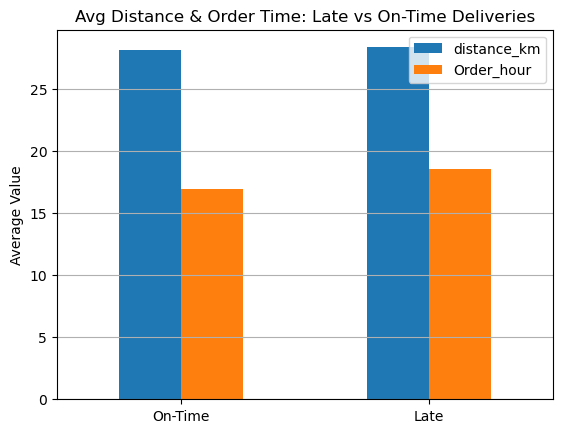

In [157]:
comparison.plot(kind='bar')

plt.title('Avg Distance & Order Time: Late vs On-Time Deliveries')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

## 11. If Delivery Distance is capped at 5 km, how much can late deliveries reduce

In [158]:
# Current late %
current_late = df['Late_Delivery'].mean() * 100
# Apply distance cap
capped_df = df[df['distance_km'] <= 5]
# New late %
capped_late = capped_df['Late_Delivery'].mean() * 100
# Reduction
reduction = current_late - capped_late

print(f"Current Late %: {current_late:.2f}%")
print(f"After 5 km Cap: {capped_late:.2f}%")
print(f"Reduction: {reduction:.2f}%")

Current Late %: 30.59%
After 5 km Cap: 12.69%
Reduction: 17.90%


In [159]:
caps = [2, 5, 8, 10]
results = {}

for cap in caps:
    capped_late = df[df['distance_km'] <= cap]['Late_Delivery'].mean() * 100
    results[f'<= {cap} km'] = capped_late
    
print(results)

{'<= 2 km': 10.361021426474904, '<= 5 km': 12.688910696761532, '<= 8 km': 16.68526457978505, '<= 10 km': 17.13012826789386}


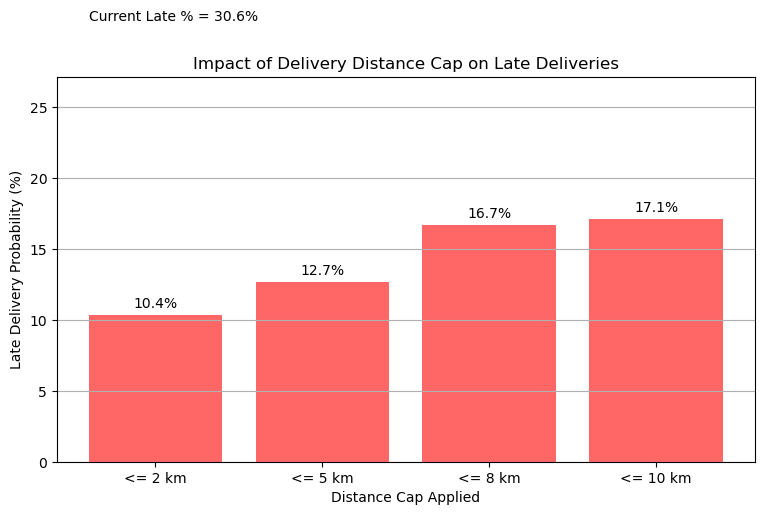

In [160]:
plt.figure(figsize=(9,5))
bars = plt.bar(results.keys(), results.values(), color = 'r', alpha = 0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', fontsize=10,)

# Reference line (current performance)
plt.axhline(current_late, linestyle='--')
plt.text(-0.4, current_late + 0.5, f'Current Late % = {current_late:.1f}%', fontsize=10)

# Titles & labels
plt.title('Impact of Delivery Distance Cap on Late Deliveries')
plt.xlabel('Distance Cap Applied')
plt.ylabel('Late Delivery Probability (%)')
plt.ylim(0, max(results.values()) + 10)
plt.grid(axis='y')
plt.show()

## 12. Can we identify high risk orders that are likely to be delivered late

In [161]:
df['High_Risk_Order'] = ((df['distance_km'] > 8) | (df['Order_hour'].isin([12,13,14,19,20,21])) |
                         (df['Road_traffic_density'] == 'Jam') | (df['Weatherconditions'].isin(['Stormy','Rainy','Fog'])) | 
                         (df['multiple_deliveries'] > 1) | (df['Delivery_person_Ratings'] < 3.5))

risk_accuracy = (df.groupby('High_Risk_Order')['Late_Delivery'].mean() * 100)
print(risk_accuracy)

df['High_Risk_Order'].value_counts()

High_Risk_Order
False     8.717883
True     36.209730
Name: Late_Delivery, dtype: float64


High_Risk_Order
True     30420
False     7823
Name: count, dtype: int64

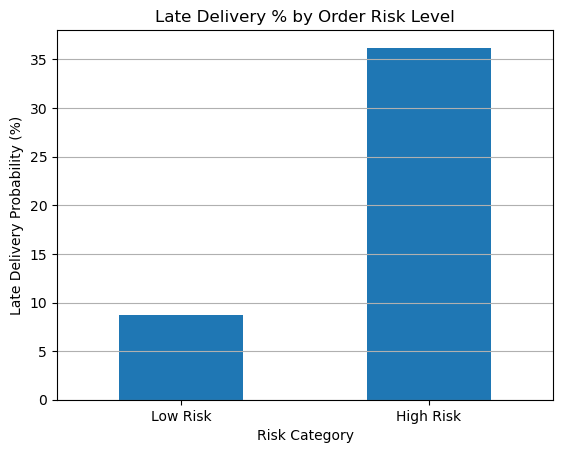

In [162]:
risk_accuracy.plot(kind='bar')

plt.title('Late Delivery % by Order Risk Level')
plt.xlabel('Risk Category')
plt.ylabel('Late Delivery Probability (%)')
plt.xticks([0,1], ['Low Risk','High Risk'], rotation=0)
plt.grid(axis='y')
plt.show()